# Swin Transformer Stage 4-5 con RoPE — Pipeline matematica e visualizzazioni
### Step-by-step: da $P_3 \in \mathbb{R}^{48 \times H/16 \times W/16}$ a $P_5 \in \mathbb{R}^{192 \times H/64 \times W/64}$

Questo notebook decostruisce i **due stage Swin** dell'encoder di HybridStyleNet,
mostrando ogni trasformazione matematica con dimensioni esplicite e visualizzando
le feature map, le mappe di attenzione e i pattern RoPE a ogni passo.

---

### Posizione nella pipeline globale

$$\underbrace{\hat{\mathbf{X}}}_{\mathbb{R}^{3\times H\times W}}
\xrightarrow{\text{MobileNetV3}}
\underbrace{P_3}_{\mathbb{R}^{48\times H/16\times W/16}}
\xrightarrow{\text{Patch Embed + Stage 4}}
\underbrace{P_4}_{\mathbb{R}^{96\times H/32\times W/32}}
\xrightarrow{\text{Patch Merge + Stage 5}}
\underbrace{P_5}_{\mathbb{R}^{192\times H/64\times W/64}}$$

Con $H=512, W=768$: $P_3 \in \mathbb{R}^{48\times32\times48}$,
$P_4 \in \mathbb{R}^{96\times16\times24}$, $P_5 \in \mathbb{R}^{192\times8\times12}$.

Ogni token in $P_5$ porta informazione contestuale dell'intera scena,
con un receptive field che copre l'immagine intera grazie alla Shifted Window Attention.


---
## Setup e caricamento $P_3$


Device: cpu
P3 caricato: (1, 40, 48, 32)
  C=40, H3=48, W3=32
  range=[-8.089, 11.776]  mean=-0.084


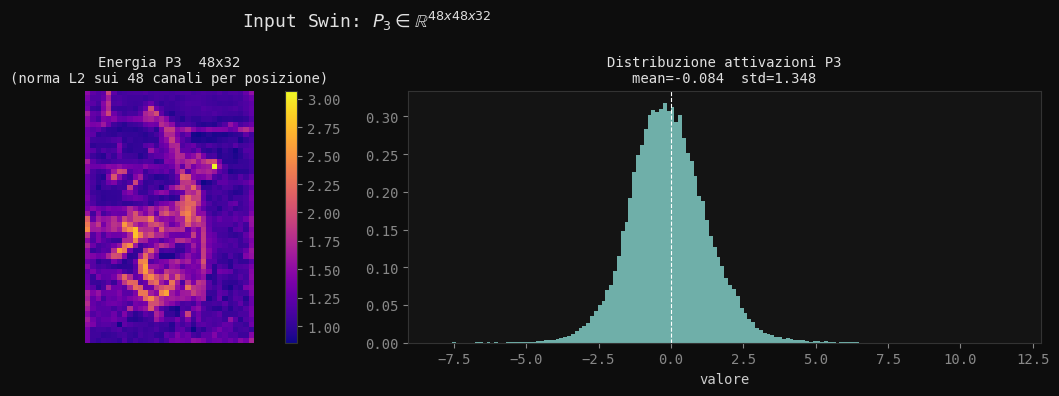

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0d0d0d', 'axes.facecolor': '#141414',
    'axes.edgecolor': '#333', 'axes.labelcolor': '#ccc',
    'xtick.color': '#888', 'ytick.color': '#888',
    'text.color': '#e0e0e0', 'axes.titlesize': 10,
    'font.family': 'monospace', 'figure.titlesize': 13,
})

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Carica P3 salvato dal notebook MobileNetV3
P3_np = np.load('P3_stem.npy')               # (1, 48, 32, 48)
P3 = torch.tensor(P3_np).float().to(DEVICE)

_, C_in, H3, W3 = P3.shape
print(f'P3 caricato: {tuple(P3.shape)}')
print(f'  C={C_in}, H3={H3}, W3={W3}')
print(f'  range=[{P3.min():.3f}, {P3.max():.3f}]  mean={P3.mean():.3f}')

# Visualizzazione: energia spaziale e prime feature map di P3
def energy(t):
    return t[0].detach().float().pow(2).mean(0).sqrt().cpu().numpy()

def show_fmaps(tensor, title, n_show=16, figsize=(18,4), cmap='inferno'):
    t = tensor[0].detach().cpu().numpy()
    C = min(n_show, t.shape[0])
    cols = min(8, C)
    rows = (C + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).flatten()
    vabs = np.percentile(np.abs(t[:C]), 95)
    im = None
    for i in range(C):
        im = axes[i].imshow(t[i], cmap=cmap, vmin=-vabs, vmax=vabs, interpolation='nearest')
        axes[i].set_title(f'ch {i}', fontsize=7, pad=2)
        axes[i].axis('off')
    for i in range(C, len(axes)):
        axes[i].axis('off')
    if im is not None:
        fig.colorbar(im, ax=axes[:C].tolist(), fraction=0.008, shrink=0.6, label='attivazione')
    fig.suptitle(title, fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
im0 = axes[0].imshow(energy(P3), cmap='plasma', interpolation='nearest')
axes[0].set_title(f'Energia P3  {H3}x{W3}\n(norma L2 sui 48 canali per posizione)')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Istogramma attivazioni
vals = P3[0].cpu().numpy().flatten()
axes[1].hist(vals, bins=150, color='#80cbc4', density=True, alpha=0.85)
axes[1].axvline(0, color='white', lw=0.8, ls='--')
axes[1].set_title(f'Distribuzione attivazioni P3\nmean={vals.mean():.3f}  std={vals.std():.3f}')
axes[1].set_xlabel('valore')

fig.suptitle(f'Input Swin: $P_3 \in \mathbb{{R}}^{{48 x {H3} x {W3}}}$')
plt.tight_layout()
plt.show()


---
## Patch Embedding — da feature map a sequenza di token
### Prima di Stage 4

Prima di entrare nel primo Swin Stage, $P_3$ deve essere convertito da una
feature map 2D in una **sequenza di token** 1D. Questo avviene tramite una
**Patch Embedding**: una convoluzione $2\times2$ con stride 2 che unifica
ogni patch $2\times2$ di feature vettori in un singolo token di dimensione $d=96$.

**Trasformazione:**

$$P_3 \in \mathbb{R}^{48 \times H_3 \times W_3}
\xrightarrow{\text{Conv}_{2\times2}^{48\to96},\ s=2}
\xrightarrow{\text{LayerNorm}}
\mathbf{Z} \in \mathbb{R}^{T \times 96}, \quad T = \frac{H_3}{2} \cdot \frac{W_3}{2} = \frac{H_3 W_3}{4}$$

Con $H_3=32, W_3=48$: $T = 16 \times 24 = 384$ token, ciascuno con $d=96$ dimensioni.

La convoluzione $2\times2$ con stride 2 è equivalente a prendere ogni patch
$2\times2$ di posizioni spaziali e proiettarla linearmente da $48 \times 2 \times 2 = 192$
a $96$ dimensioni. In termini di posizioni spaziali originali, ogni token
copre ora una regione $32\times32$ px dell'input (stride cumulativo $16 \times 2 = 32$).

**Layer Normalization** (applicata per token, non per canale come BN):
$$\text{LN}(\mathbf{z}) = \gamma \odot \frac{\mathbf{z} - \mu_z}{\sqrt{\sigma^2_z + \varepsilon}} + \beta, \quad \mu_z = \frac{1}{d}\sum_{j=1}^d z_j, \quad \sigma^2_z = \frac{1}{d}\sum_{j=1}^d (z_j - \mu_z)^2$$

A differenza di BN che normalizza sulla dimensione batch/spaziale,
LN normalizza sulla dimensione delle feature per ogni token individualmente —
più stabile per sequenze di lunghezza variabile.


P3 -> Z (patch embed):
  Input:  (1, 40, 48, 32)
  Output: (1, 384, 96)   T=384 token, d=96
  Griglia token: 24 x 16
  Z range=[-3.840, 4.208]  std=1.000


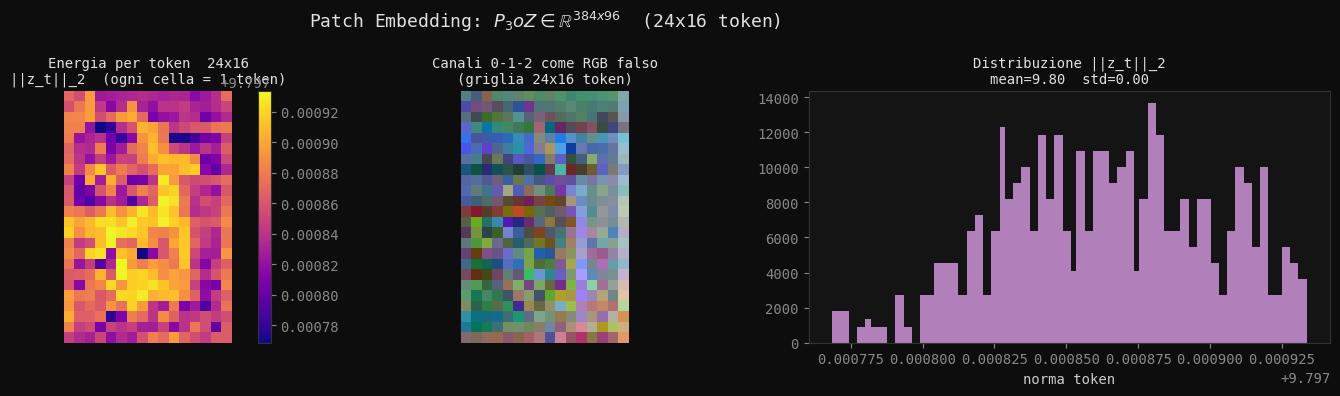

In [4]:
# Implementazione Patch Embedding
class PatchEmbed(nn.Module):
    def __init__(self, in_ch=48, embed_dim=96, patch_size=2):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.norm = nn.LayerNorm(embed_dim)
        self.patch_size = patch_size
        self.embed_dim  = embed_dim

    def forward(self, x):
        # x: (1, C, H, W)
        x = self.proj(x)                      # (1, embed_dim, H/2, W/2)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)      # (1, T, embed_dim) con T = H*W
        x = self.norm(x)
        return x, H, W                        # ritorna anche H, W per ricostruire la griglia

torch.manual_seed(0)
patch_embed = PatchEmbed(in_ch=C_in, embed_dim=96, patch_size=2).to(DEVICE)

with torch.no_grad():
    Z, H4, W4 = patch_embed(P3)              # Z: (1, T, 96)

T = H4 * W4
print(f'P3 -> Z (patch embed):')
print(f'  Input:  {tuple(P3.shape)}')
print(f'  Output: {tuple(Z.shape)}   T={T} token, d=96')
print(f'  Griglia token: {H4} x {W4}')
print(f'  Z range=[{Z.min():.3f}, {Z.max():.3f}]  std={Z.std():.3f}')

# Visualizzazione: Z come griglia 2D (prima di flatten)
Z_grid = Z[0].detach().cpu().numpy().reshape(H4, W4, 96)  # (H4, W4, 96)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Energia per token
token_energy = np.linalg.norm(Z_grid, axis=2)
im0 = axes[0].imshow(token_energy, cmap='plasma', interpolation='nearest')
axes[0].set_title(f'Energia per token  {H4}x{W4}\n||z_t||_2  (ogni cella = 1 token)')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Primi 3 canali come RGB falsi
rgb_fake = Z_grid[:,:,:3]
rgb_fake = (rgb_fake - rgb_fake.min()) / (rgb_fake.max() - rgb_fake.min() + 1e-8)
axes[1].imshow(rgb_fake, interpolation='nearest')
axes[1].set_title(f'Canali 0-1-2 come RGB falso\n(griglia {H4}x{W4} token)')
axes[1].axis('off')

# Distribuzione norma token
norms = token_energy.flatten()
axes[2].hist(norms, bins=60, color='#ce93d8', density=True, alpha=0.85)
axes[2].set_title(f'Distribuzione ||z_t||_2\nmean={norms.mean():.2f}  std={norms.std():.2f}')
axes[2].set_xlabel('norma token')

fig.suptitle(f'Patch Embedding: $P_3 \to Z \in \mathbb{{R}}^{{{T} x 96}}$  ({H4}x{W4} token)')
plt.tight_layout()
plt.show()


---
## Rotary Position Embedding (RoPE)
### Codifica posizionale resolution-agnostic

Il positional encoding assoluto standard (APE) aggiunge un vettore appreso
$\mathbf{p}_m \in \mathbb{R}^d$ al token in posizione $m$. Il problema è che
questo vettore esiste solo per le posizioni viste durante il training: se si addestra
su crop $512\times384$ ma si fa inferenza su $6048\times4024$, le posizioni
$> T_{train}$ non hanno embedding — **distribution shift posizionale**.

RoPE risolve questo codificando la posizione come **rotazione** nel piano complesso,
in modo che il prodotto scalare tra due token dipenda solo dalla loro **distanza relativa**.

---

### Costruzione del RoPE 1D

Per ogni coppia di dimensioni $(2j-1, 2j)$ del vettore query $\mathbf{q}$,
si definisce la frequenza:

$$\theta_j = \frac{1}{10000^{2j/d}}, \quad j = 1, \ldots, d/2$$

Le frequenze scalano geometricamente da $\theta_1 = 1$ a $\theta_{d/2} = 10000^{-1}$,
coprendo scale di periodicità da $2\pi$ a $2\pi \cdot 10000$ — analogo al
sinusoidal encoding di Vaswani et al. ma applicato come rotazione.

La trasformazione del query in posizione $m$ è:

$$f(\mathbf{q}, m)_{2j-1} = q_{2j-1}\cos(m\theta_j) - q_{2j}\sin(m\theta_j)$$
$$f(\mathbf{q}, m)_{2j}   = q_{2j-1}\sin(m\theta_j) + q_{2j}\cos(m\theta_j)$$

che in notazione complessa è $f(\mathbf{q}, m)_j = (q_{2j-1} + iq_{2j}) \cdot e^{im\theta_j}$.

---

### Proprietà chiave: dipendenza dalla distanza relativa

Il prodotto scalare tra query in posizione $m$ e key in posizione $n$:

$$\langle f(\mathbf{q},m),\, f(\mathbf{k},n) \rangle
= \sum_{j=1}^{d/2} \text{Re}\!\left[(q_{2j-1}+iq_{2j})(k_{2j-1}-ik_{2j})\,e^{i(m-n)\theta_j}\right]
= g(\mathbf{q},\mathbf{k},\underbrace{m-n}_{\text{solo distanza}})$$

Il risultato dipende **solo da $m-n$**, non dai valori assoluti $m$ e $n$.
Questo significa che un pattern "pixel A è vicino a pixel B" viene riconosciuto
correttamente a qualsiasi risoluzione — il modello addestrato a $512\times384$
funziona a $6048\times4024$ senza retraining.

---

### RoPE 2D per immagini

Per token in una griglia 2D con posizione $(r, c)$, si applica RoPE separatamente
sulle prime $d/2$ dimensioni con posizione $r$ e sulle ultime $d/2$ con posizione $c$:

$$f_{2D}(\mathbf{q}, r, c)_j = \begin{cases}
f(\mathbf{q}_{:d/2}, r)_j & j \leq d/2 \\
f(\mathbf{q}_{d/2:}, c)_{j-d/2} & j > d/2
\end{cases}$$


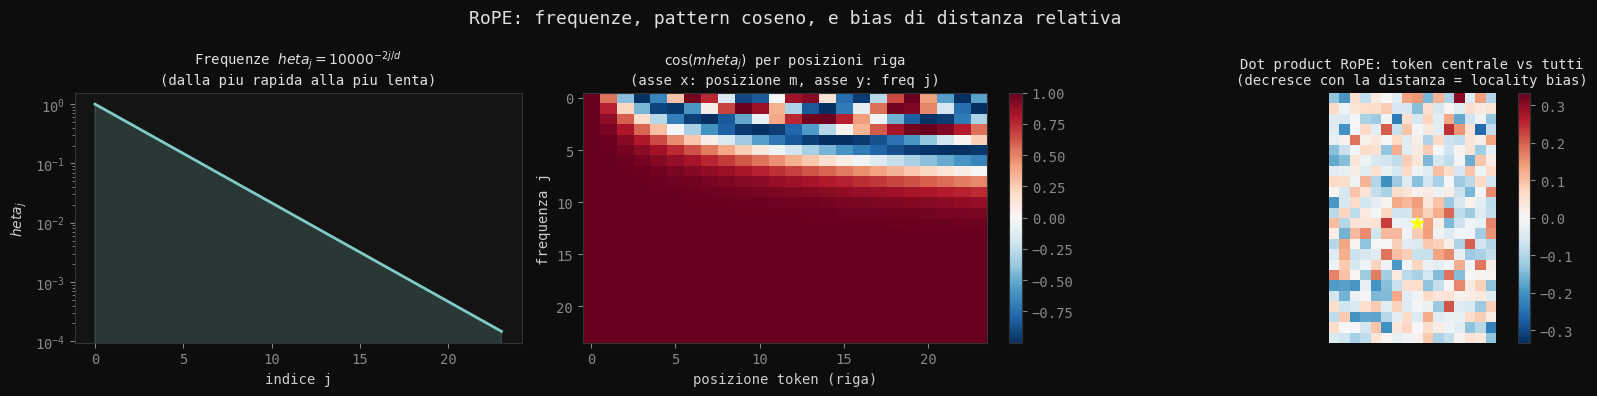

In [5]:
# Implementazione RoPE
def build_rope_freqs(seq_len, dim, base=10000, device='cpu'):
    '''
    Costruisce le frequenze theta_j per RoPE 1D.
    dim: dimensione del vettore (d o d/2 per 2D)
    Ritorna: freqs (seq_len, dim//2) — angoli m*theta_j per ogni posizione m
    '''
    half_dim = dim // 2
    # theta_j = 1 / 10000^(2j/dim), j = 0,...,half_dim-1
    theta = 1.0 / (base ** (torch.arange(0, half_dim, dtype=torch.float32) / half_dim))
    theta = theta.to(device)
    positions = torch.arange(seq_len, dtype=torch.float32, device=device)
    freqs = torch.outer(positions, theta)   # (seq_len, half_dim) = m * theta_j
    return freqs

def apply_rope_1d(x, freqs):
    '''
    Applica RoPE 1D a x: (B, T, d)
    freqs: (T, d//2)
    '''
    d = x.shape[-1]
    half = d // 2
    x1, x2 = x[..., :half], x[..., half:]         # split in due metà
    cos_f = freqs.cos().unsqueeze(0)                # (1, T, half)
    sin_f = freqs.sin().unsqueeze(0)
    # rotazione: [x1*cos - x2*sin, x1*sin + x2*cos]
    return torch.cat([x1 * cos_f - x2 * sin_f,
                      x1 * sin_f + x2 * cos_f], dim=-1)

def apply_rope_2d(q, k, H, W, dim):
    '''
    RoPE 2D: applica RoPE separatamente su righe (dim[:d/2]) e colonne (dim[d/2:]).
    q, k: (B, T, d) con T = H*W
    '''
    half_d = dim // 2
    freqs_r = build_rope_freqs(H, half_d, device=q.device)  # (H, half_d//2)
    freqs_c = build_rope_freqs(W, half_d, device=q.device)  # (W, half_d//2)

    # Espandi le frequenze alla griglia H x W
    freqs_r_grid = freqs_r.unsqueeze(1).expand(H, W, -1).reshape(H*W, -1)  # (T, half_d//2)
    freqs_c_grid = freqs_c.unsqueeze(0).expand(H, W, -1).reshape(H*W, -1)

    q_r, q_c = q[..., :half_d], q[..., half_d:]
    k_r, k_c = k[..., :half_d], k[..., half_d:]

    q_rot = torch.cat([apply_rope_1d(q_r, freqs_r_grid),
                       apply_rope_1d(q_c, freqs_c_grid)], dim=-1)
    k_rot = torch.cat([apply_rope_1d(k_r, freqs_r_grid),
                       apply_rope_1d(k_c, freqs_c_grid)], dim=-1)
    return q_rot, k_rot

# Visualizzazione: mappe di frequenza RoPE
d = 96
freqs_row = build_rope_freqs(H4, d//2)   # (16, 24)
freqs_col = build_rope_freqs(W4, d//2)   # (24, 24)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Spettro delle frequenze theta_j
half = d // 4
theta_vals = 1.0 / (10000 ** (torch.arange(0, half).float() / half))
axes[0].plot(theta_vals.numpy(), color='#80cbc4', lw=2)
axes[0].fill_between(range(len(theta_vals)), theta_vals.numpy(), alpha=0.2, color='#80cbc4')
axes[0].set_title('Frequenze $\theta_j = 10000^{-2j/d}$\n(dalla piu rapida alla piu lenta)')
axes[0].set_xlabel('indice j')
axes[0].set_ylabel('$\theta_j$')
axes[0].set_yscale('log')

# Mappa cos(m * theta_j) per posizioni righe
cos_map = freqs_row.cos().numpy()   # (H4, d//4)
im1 = axes[1].imshow(cos_map.T, aspect='auto', cmap='RdBu_r', interpolation='nearest')
axes[1].set_title(f'$\cos(m\theta_j)$ per posizioni riga\n(asse x: posizione m, asse y: freq j)')
axes[1].set_xlabel('posizione token (riga)')
axes[1].set_ylabel('frequenza j')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Distanza relativa: dot product RoPE per token fisso vs tutti gli altri
# Simula q e k come vettori unitari casuali
torch.manual_seed(7)
q_test = torch.randn(1, H4*W4, d) / math.sqrt(d)
k_test = torch.randn(1, H4*W4, d) / math.sqrt(d)
q_rot, k_rot = apply_rope_2d(q_test, k_test, H4, W4, d)

# Dot product tra token centrale e tutti gli altri (con e senza RoPE)
center = (H4//2) * W4 + W4//2
dot_no_rope  = (q_test[0, center] * k_test[0]).sum(-1).reshape(H4, W4).detach().numpy()
dot_with_rope = (q_rot[0, center] * k_rot[0]).sum(-1).reshape(H4, W4).detach().numpy()

vabs = max(np.abs(dot_with_rope).max(), np.abs(dot_no_rope).max())
im2 = axes[2].imshow(dot_with_rope, cmap='RdBu_r', vmin=-vabs, vmax=vabs, interpolation='nearest')
axes[2].set_title(f'Dot product RoPE: token centrale vs tutti\n'
                   '(decresce con la distanza = locality bias)')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)
axes[2].scatter([W4//2], [H4//2], c='yellow', s=80, zorder=5, marker='*')

fig.suptitle('RoPE: frequenze, pattern coseno, e bias di distanza relativa')
plt.tight_layout()
plt.show()

---
## Window Partition — divisione in finestre $M\times M$
### Prima della W-MSA

Lo Swin Transformer suddivide la griglia di token $H_4 \times W_4$ in finestre
non sovrapposte di $M \times M$ token ($M=7$ per default). L'attention è poi
calcolata **solo all'interno** di ciascuna finestra, riducendo la complessità
da $O(T^2)$ a $O(T \cdot M^2)$.

**Operazione di window partition:**

Sia $\mathbf{Z} \in \mathbb{R}^{H_4 \times W_4 \times d}$ la griglia di token.
La partizione in finestre produce:

$$\mathbf{Z}_{win} \in \mathbb{R}^{N_w \times M^2 \times d}, \quad N_w = \frac{H_4}{M} \cdot \frac{W_4}{M}$$

dove $N_w$ è il numero di finestre. Ogni finestra contiene $M^2 = 49$ token.

Con $H_4=16, W_4=24, M=7$: $N_w = \frac{16}{7} \cdot \frac{24}{7}$ — ma $16$ e $24$
non sono divisibili per $7$! In questo caso si usa il **padding ciclico** (reflect padding)
per portare la griglia a dimensioni divisibili per $M$:

$$H_4' = \lceil H_4/M \rceil \cdot M, \quad W_4' = \lceil W_4/M \rceil \cdot M$$

**Shifted Window (SW-MSA).** Per garantire connettività tra finestre adiacenti,
i layer pari usano W-MSA e i layer dispari usano SW-MSA, dove le finestre
sono traslate di $(\lfloor M/2 \rfloor, \lfloor M/2 \rfloor) = (3,3)$ token:

$$\mathbf{Z}_{shifted} = \text{cyclic\_shift}(\mathbf{Z},\ \text{shift}=(-3,-3))$$

Dopo la traslazione ciclica, le finestre tagliano regioni diverse dell'immagine
— token che prima erano ai bordi opposti ora sono nella stessa finestra e
possono interagire. Un **attention mask** blocca le interazioni tra token
che non erano originariamente adiacenti prima dello shift.


Window partition:
  Input:   (1, 24, 16, 96)   (B, H4, W4, d)
  Padding: 24->28, 16->21  (multipli di M=7)
  Finestre: 4 x 3 = 12
  Output:  (12, 49, 96)   (N_win, M^2, d)

Shifted window partition (shift=3):
  Output:  (12, 49, 96)


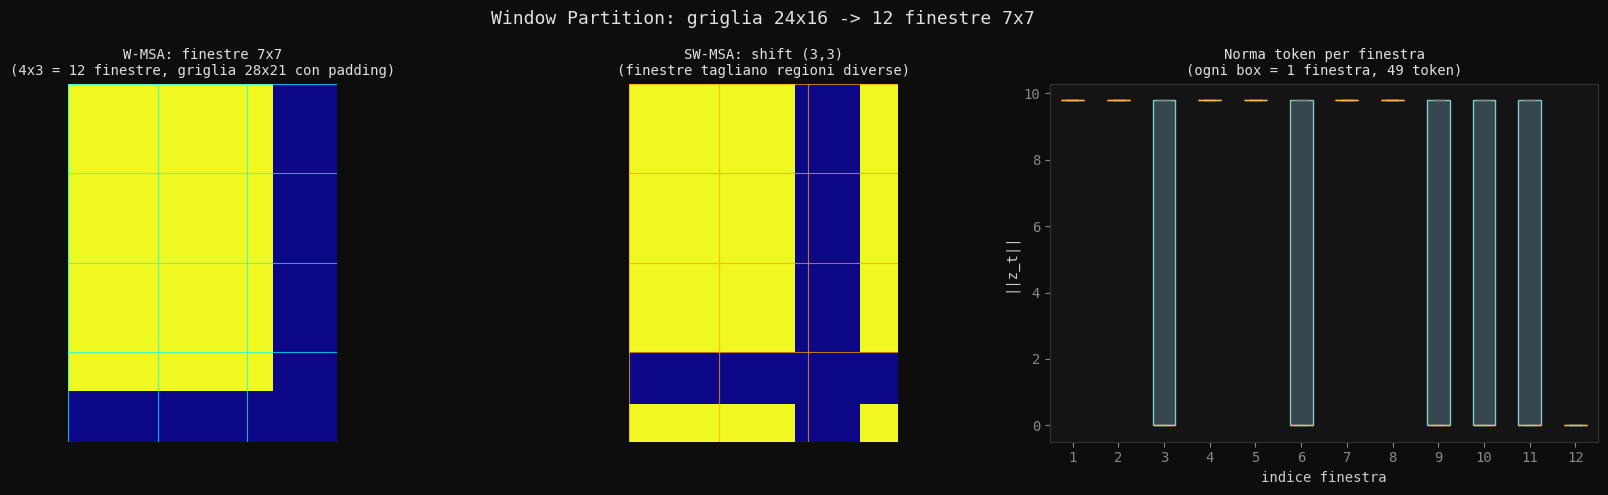

In [6]:
# Implementazione window partition / reverse
def window_partition(x, M):
    '''
    x: (B, H, W, C)
    Ritorna: (B*num_windows, M, M, C) e (num_windows_h, num_windows_w)
    Con padding se H o W non divisibili per M.
    '''
    B, H, W, C = x.shape
    # Padding
    pad_h = (M - H % M) % M
    pad_w = (M - W % M) % M
    if pad_h > 0 or pad_w > 0:
        x = F.pad(x, (0, 0, 0, pad_w, 0, pad_h))
    _, Hp, Wp, _ = x.shape
    nH, nW = Hp // M, Wp // M
    x = x.view(B, nH, M, nW, M, C)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous()   # (B, nH, nW, M, M, C)
    x = x.view(B * nH * nW, M * M, C)
    return x, nH, nW, Hp, Wp

def window_reverse(x, M, nH, nW, Hp, Wp, H_orig, W_orig):
    '''Inverso di window_partition.'''
    B_nw = x.shape[0]
    B = B_nw // (nH * nW)
    x = x.view(B, nH, nW, M, M, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, Hp, Wp, -1)
    return x[:, :H_orig, :W_orig, :].contiguous()

M = 7
# Z_grid: (1, T, 96) -> (1, H4, W4, 96)
Z_grid_4d = Z.reshape(1, H4, W4, 96)

# Window partition
Z_win, nH, nW, Hp, Wp = window_partition(Z_grid_4d, M)
print(f'Window partition:')
print(f'  Input:   {tuple(Z_grid_4d.shape)}   (B, H4, W4, d)')
print(f'  Padding: {H4}->{Hp}, {W4}->{Wp}  (multipli di M={M})')
print(f'  Finestre: {nH} x {nW} = {nH*nW}')
print(f'  Output:  {tuple(Z_win.shape)}   (N_win, M^2, d)')

# Shift per SW-MSA
shift = M // 2
Z_shifted = torch.roll(Z_grid_4d, shifts=(-shift, -shift), dims=(1, 2))
Z_win_sw, nH_sw, nW_sw, Hp_sw, Wp_sw = window_partition(Z_shifted, M)
print(f'\nShifted window partition (shift={shift}):')
print(f'  Output:  {tuple(Z_win_sw.shape)}')

# Visualizzazione: griglia finestre
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Energia per token come griglia colorata con overlay finestre
tok_energy = np.linalg.norm(Z_grid_4d[0].detach().cpu().numpy(), axis=-1)  # (H4, W4)

# Padding visualizzazione
tok_energy_pad = np.zeros((Hp, Wp))
tok_energy_pad[:H4, :W4] = tok_energy

axes[0].imshow(tok_energy_pad, cmap='plasma', interpolation='nearest')
for i in range(0, Hp, M):
    axes[0].axhline(i - 0.5, color='cyan', lw=0.8, alpha=0.7)
for j in range(0, Wp, M):
    axes[0].axvline(j - 0.5, color='cyan', lw=0.8, alpha=0.7)
axes[0].set_title(f'W-MSA: finestre {M}x{M}\n({nH}x{nW} = {nH*nW} finestre, griglia {Hp}x{Wp} con padding)')
axes[0].axis('off')

# Shifted window
tok_shifted = np.roll(tok_energy_pad, (-shift, -shift), axis=(0,1))
axes[1].imshow(tok_shifted, cmap='plasma', interpolation='nearest')
for i in range(0, Hp, M):
    axes[1].axhline(i - 0.5, color='orange', lw=0.8, alpha=0.7)
for j in range(0, Wp, M):
    axes[1].axvline(j - 0.5, color='orange', lw=0.8, alpha=0.7)
axes[1].set_title(f'SW-MSA: shift ({shift},{shift})\n(finestre tagliano regioni diverse)')
axes[1].axis('off')

# Distribuzione norm token per finestra
win_norms = Z_win.detach().cpu().norm(dim=-1).numpy()  # (N_win, M^2)
axes[2].boxplot(win_norms.T, patch_artist=True,
                boxprops=dict(facecolor='#37474f', color='#80cbc4'),
                medianprops=dict(color='#ffb74d'),
                whiskerprops=dict(color='#888'),
                capprops=dict(color='#888'),
                flierprops=dict(marker='.', color='#555', markersize=2),
                showfliers=False)
axes[2].set_title(f'Norma token per finestra\n(ogni box = 1 finestra, {M*M} token)')
axes[2].set_xlabel('indice finestra')
axes[2].set_ylabel('||z_t||')
if nH * nW > 20:
    axes[2].set_xticks([])

fig.suptitle(f'Window Partition: griglia {H4}x{W4} -> {nH*nW} finestre {M}x{M}')
plt.tight_layout()
plt.show()


---
## Window Multi-Head Self-Attention (W-MSA) con RoPE
### Il cuore dello Swin Stage

Per ogni finestra con token $\mathbf{Z}_{win} \in \mathbb{R}^{M^2 \times d}$,
la W-MSA con $h=4$ teste calcola:

$$\text{W-MSA}(\mathbf{Z}_{win}) = \text{Concat}(\text{head}_1, \ldots, \text{head}_4)\,\mathbf{W}^O \in \mathbb{R}^{M^2 \times d}$$

**Per ogni testa $k \in \{1,\ldots,4\}$** con dimensione per testa $d_h = d/h = 96/4 = 24$:

$$\mathbf{Q}_k = \mathbf{Z}_{win}\mathbf{W}_k^Q \in \mathbb{R}^{M^2 \times 24}, \quad
\mathbf{K}_k = \mathbf{Z}_{win}\mathbf{W}_k^K \in \mathbb{R}^{M^2 \times 24}, \quad
\mathbf{V}_k = \mathbf{Z}_{win}\mathbf{W}_k^V \in \mathbb{R}^{M^2 \times 24}$$

**Applicazione RoPE** a Q e K (non a V — V trasporta contenuto, non posizione):

$$\tilde{\mathbf{Q}}_k = \text{RoPE}_{2D}(\mathbf{Q}_k, M, M), \quad
\tilde{\mathbf{K}}_k = \text{RoPE}_{2D}(\mathbf{K}_k, M, M)$$

**Attention score con scaling:**

$$\mathbf{A}_k = \text{Softmax}\!\left(\frac{\tilde{\mathbf{Q}}_k \tilde{\mathbf{K}}_k^T}{\sqrt{d_h}}\right) \in \mathbb{R}^{M^2 \times M^2}$$

Il fattore $1/\sqrt{d_h} = 1/\sqrt{24}$ normalizza il dot product per evitare
che cresca troppo in magnitude al crescere di $d_h$, stabilizzando il gradiente
della softmax (senza scaling, la softmax satura su configurazioni quasi one-hot).

**Output della testa:**

$$\text{head}_k = \mathbf{A}_k \mathbf{V}_k \in \mathbb{R}^{M^2 \times 24}$$

**Concatenazione e proiezione finale:**

$$\text{W-MSA}(\mathbf{Z}_{win}) = \text{Concat}(\text{head}_1,\ldots,\text{head}_4)\,\mathbf{W}^O \in \mathbb{R}^{M^2 \times 96}$$

**Complessità per finestra:** $O(M^4 \cdot d)$ — con $M=7$: $49^2 \cdot 96 \approx 230K$ operazioni per finestra, indipendente dalla risoluzione totale.


In [7]:
# Implementazione W-MSA con RoPE
class WindowMSA_RoPE(nn.Module):
    def __init__(self, dim, num_heads=4, window_size=7):
        super().__init__()
        self.dim        = dim
        self.num_heads  = num_heads
        self.head_dim   = dim // num_heads
        self.scale      = self.head_dim ** -0.5
        self.window_size = window_size

        self.qkv  = nn.Linear(dim, dim * 3, bias=True)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x_win, H_win=None, W_win=None):
        # x_win: (B*N_win, M^2, dim)
        BN, L, C = x_win.shape
        H_w = W_w = self.window_size
        if H_win is not None: H_w, W_w = H_win, W_win

        qkv = self.qkv(x_win)                                     # (BN, L, 3*dim)
        qkv = qkv.reshape(BN, L, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)                          # (3, BN, h, L, head_dim)
        q, k, v = qkv.unbind(0)                                    # ciascuno (BN, h, L, head_dim)

        # Applica RoPE 2D a Q e K (per ogni testa separatamente)
        q_rot_list, k_rot_list = [], []
        for hi in range(self.num_heads):
            q_h = q[:, hi, :, :]   # (BN, L, head_dim)
            k_h = k[:, hi, :, :]
            q_r, k_r = apply_rope_2d(q_h, k_h, H_w, W_w, self.head_dim)
            q_rot_list.append(q_r)
            k_rot_list.append(k_r)
        q = torch.stack(q_rot_list, dim=1)   # (BN, h, L, head_dim)
        k = torch.stack(k_rot_list, dim=1)

        # Attention
        attn = (q @ k.transpose(-2, -1)) * self.scale             # (BN, h, L, L)
        attn = attn.softmax(dim=-1)

        out = (attn @ v)                                           # (BN, h, L, head_dim)
        out = out.transpose(1, 2).reshape(BN, L, C)               # (BN, L, dim)
        out = self.proj(out)
        return out, attn

torch.manual_seed(0)
wmsa = WindowMSA_RoPE(dim=96, num_heads=4, window_size=M).to(DEVICE)

with torch.no_grad():
    Z_win_out, attn_maps = wmsa(Z_win, H_win=M, W_win=M)

print(f'W-MSA input:  {tuple(Z_win.shape)}   (N_win x M^2 x d)')
print(f'W-MSA output: {tuple(Z_win_out.shape)}')
print(f'Attn maps:    {tuple(attn_maps.shape)}  (N_win x h x M^2 x M^2)')


W-MSA input:  (12, 49, 96)   (N_win x M^2 x d)
W-MSA output: (12, 49, 96)
Attn maps:    (12, 4, 49, 49)  (N_win x h x M^2 x M^2)


Finestra selezionata: indice 7  (centrale 2,1)


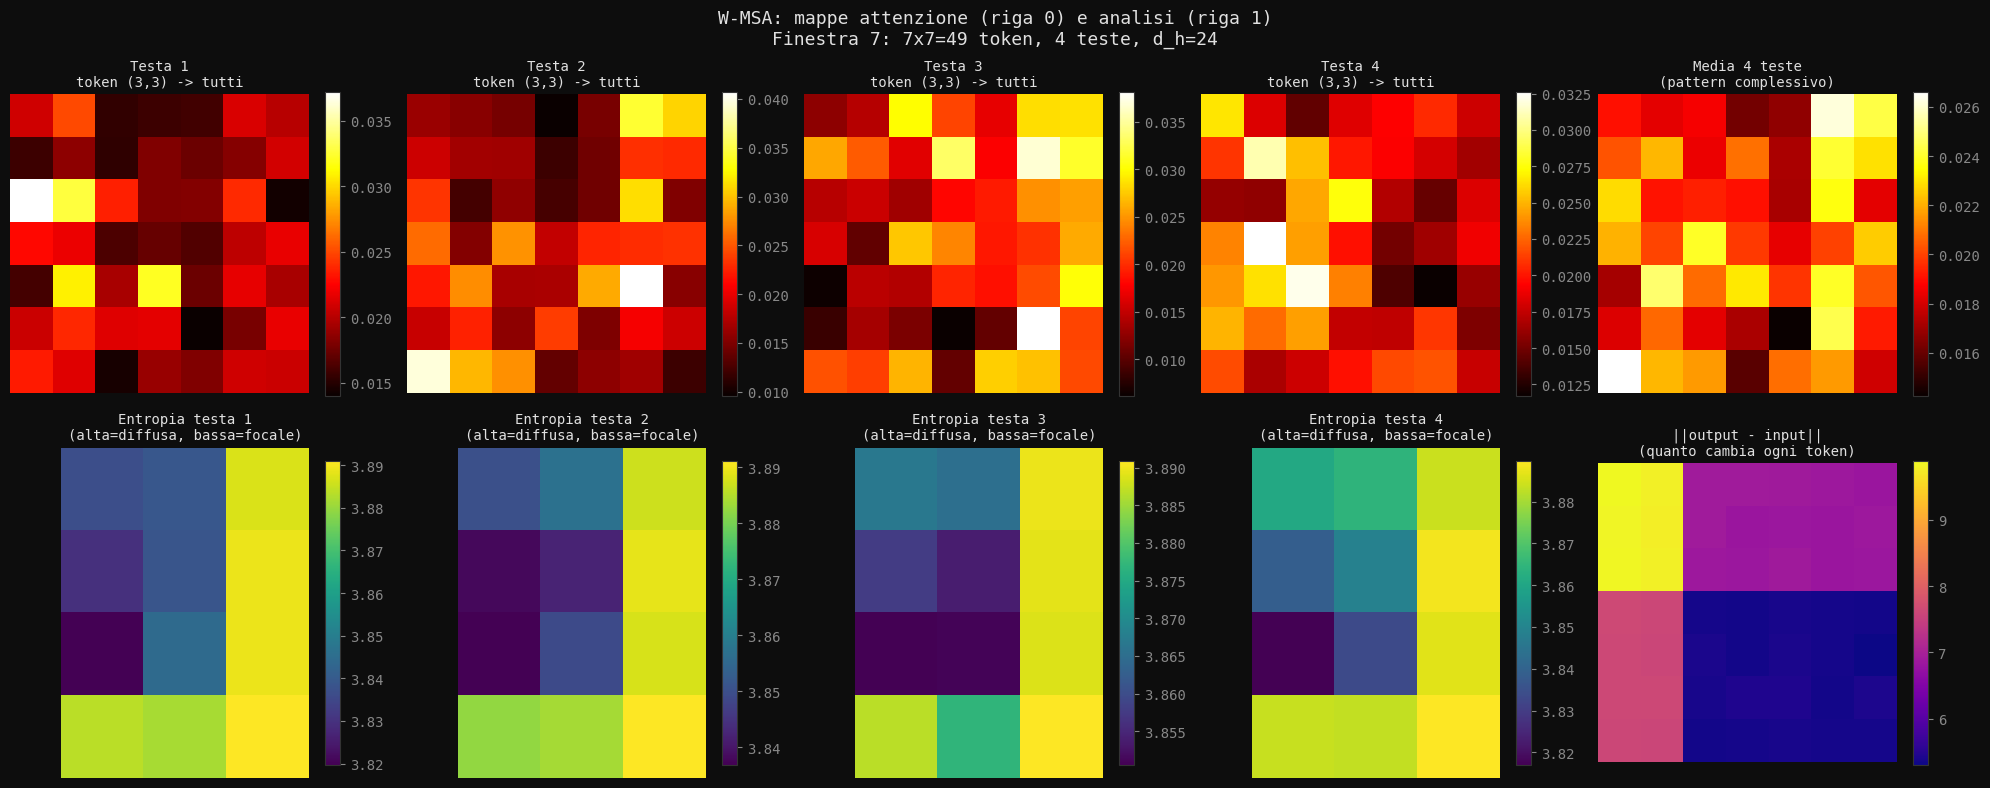

In [8]:
# Visualizzazione mappe di attenzione
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

# Scegli una finestra centrale da visualizzare
win_idx = (nH // 2) * nW + (nW // 2)
print(f'Finestra selezionata: indice {win_idx}  (centrale {nH//2},{nW//2})')

attn_win = attn_maps[win_idx].detach().cpu().numpy()   # (h, M^2, M^2)

# Riga 0: mappe attenzione per le 4 teste (token centrale -> tutti gli altri)
center_tok = (M//2) * M + M//2   # token centrale della finestra
for hi in range(4):
    a = attn_win[hi, center_tok].reshape(M, M)
    im = axes[0, hi].imshow(a, cmap='hot', interpolation='nearest')
    axes[0, hi].set_title(f'Testa {hi+1}\ntoken ({M//2},{M//2}) -> tutti')
    axes[0, hi].axis('off')
    plt.colorbar(im, ax=axes[0, hi], fraction=0.046)

# Attenzione media su tutte le teste
avg_attn = attn_win.mean(0)[center_tok].reshape(M, M)
im_avg = axes[0, 4].imshow(avg_attn, cmap='hot', interpolation='nearest')
axes[0, 4].set_title(f'Media 4 teste\n(pattern complessivo)')
axes[0, 4].axis('off')
plt.colorbar(im_avg, ax=axes[0, 4], fraction=0.046)

# Riga 1: entropia di attenzione per finestra (misura quanto e distribuita)
def attn_entropy(a):
    a = a + 1e-9
    return -(a * np.log(a)).sum(-1).mean()   # media sui token sorgente

entropies = np.array([attn_maps[w].detach().cpu().numpy().mean(1) for w in range(nH*nW)])
# entropies: (N_win, h, M^2)

for hi in range(4):
    ent_map = np.array([attn_entropy(attn_maps[w, hi].detach().cpu().numpy())
                        for w in range(nH*nW)]).reshape(nH, nW)
    im_e = axes[1, hi].imshow(ent_map, cmap='viridis', interpolation='nearest')
    axes[1, hi].set_title(f'Entropia testa {hi+1}\n(alta=diffusa, bassa=focale)')
    axes[1, hi].axis('off')
    plt.colorbar(im_e, ax=axes[1, hi], fraction=0.046)

# Delta: output - input (cosa ha aggiunto la W-MSA)
delta = (Z_win_out - Z_win).detach().cpu().norm(dim=-1).mean(0).reshape(M, M)
im_d = axes[1, 4].imshow(delta.numpy(), cmap='plasma', interpolation='nearest')
axes[1, 4].set_title('||output - input||\n(quanto cambia ogni token)')
axes[1, 4].axis('off')
plt.colorbar(im_d, ax=axes[1, 4], fraction=0.046)

fig.suptitle(f'W-MSA: mappe attenzione (riga 0) e analisi (riga 1)\n'
             f'Finestra {win_idx}: {M}x{M}={M*M} token, 4 teste, d_h=24')
plt.tight_layout()
plt.show()


---
## Swin Block completo — W-MSA + MLP + LayerNorm + Residual

Un singolo **Swin Block** segue lo schema pre-norm (LN prima dell'attenzione):

$$\mathbf{Z}' = \mathbf{Z} + \text{W-MSA}(\text{LN}_1(\mathbf{Z}))$$
$$\mathbf{Z}'' = \mathbf{Z}' + \text{MLP}(\text{LN}_2(\mathbf{Z}'))$$

**MLP a 2 strati** con expansion ratio 4:

$$\text{MLP}(\mathbf{z}) = \mathbf{W}_2\,\text{GELU}(\mathbf{W}_1\,\mathbf{z} + \mathbf{b}_1) + \mathbf{b}_2$$

con $\mathbf{W}_1 \in \mathbb{R}^{4d\times d}$, $\mathbf{W}_2 \in \mathbb{R}^{d\times 4d}$ —
proietta da $d=96$ a $4d=384$ e poi torna a $d=96$.

**GELU** (Gaussian Error Linear Unit):
$$\text{GELU}(x) = x \cdot \Phi(x) \approx x \cdot \sigma(1.702\,x)$$

dove $\Phi$ è la CDF della gaussiana standard. GELU è preferito a ReLU nei
Transformer per la sua natura smooth e la derivata non-zero per $x<0$.

**Schema con due layer alternati (W-MSA poi SW-MSA):**

$$\mathbf{Z}^{(0)} \xrightarrow{\text{Swin Block W-MSA}} \mathbf{Z}^{(1)}
\xrightarrow{\text{Swin Block SW-MSA}} \mathbf{Z}^{(2)}$$

I layer si alternano in coppie: il primo usa W-MSA (finestre fisse),
il secondo usa SW-MSA (finestre traslate di $M/2$).


Input Z:    (1, 384, 96)
Z1 (W-MSA): (1, 384, 96)  range=[-3.959, 4.763]
Z2 (SW-MSA):(1, 384, 96)  range=[-4.136, 4.883]


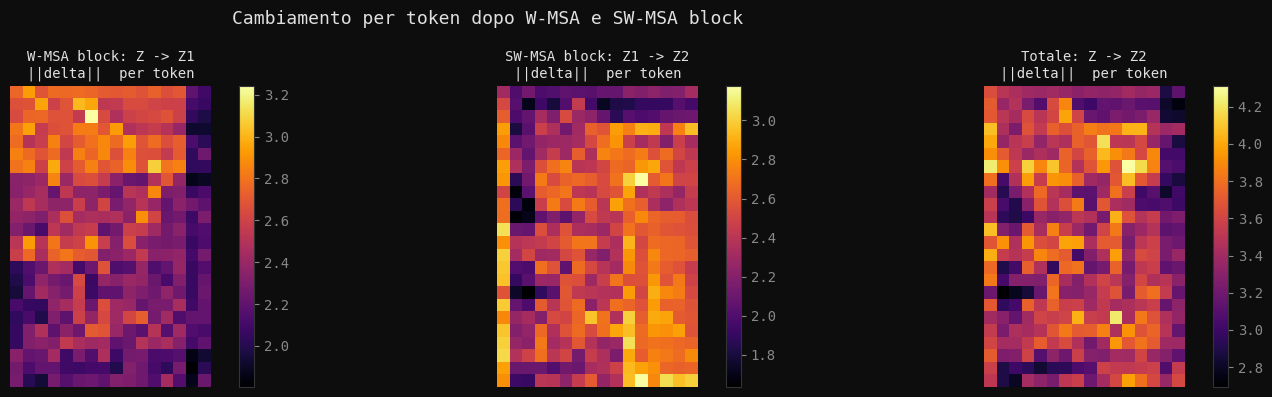

In [9]:
# Swin Block completo
class SwinBlock(nn.Module):
    def __init__(self, dim, num_heads=4, window_size=7, shift=False, mlp_ratio=4.0):
        super().__init__()
        self.shift       = shift
        self.window_size = window_size
        self.shift_size  = window_size // 2 if shift else 0

        self.norm1 = nn.LayerNorm(dim)
        self.attn  = WindowMSA_RoPE(dim, num_heads, window_size)
        self.norm2 = nn.LayerNorm(dim)

        mlp_hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden),
            nn.GELU(),
            nn.Linear(mlp_hidden, dim),
        )

    def forward(self, x, H, W):
        # x: (B, T, d)  T = H*W
        B, T, C = x.shape
        shortcut = x

        x = self.norm1(x)
        x_2d = x.view(B, H, W, C)

        # Cyclic shift per SW-MSA
        if self.shift_size > 0:
            x_2d = torch.roll(x_2d, shifts=(-self.shift_size, -self.shift_size), dims=(1,2))

        # Window partition
        x_win, nH, nW, Hp, Wp = window_partition(x_2d, self.window_size)

        # W-MSA con RoPE
        x_win, attn = self.attn(x_win, H_win=self.window_size, W_win=self.window_size)

        # Window reverse
        x_2d = window_reverse(x_win, self.window_size, nH, nW, Hp, Wp, H, W)

        # Reverse shift
        if self.shift_size > 0:
            x_2d = torch.roll(x_2d, shifts=(self.shift_size, self.shift_size), dims=(1,2))

        x = x_2d.view(B, T, C)

        # Residual 1
        x = shortcut + x

        # MLP + Residual 2
        x = x + self.mlp(self.norm2(x))
        return x, attn

torch.manual_seed(0)
block_wmsa = SwinBlock(dim=96, num_heads=4, window_size=M, shift=False).to(DEVICE)
block_swmsa = SwinBlock(dim=96, num_heads=4, window_size=M, shift=True).to(DEVICE)

Z_seq = Z   # (1, T, 96)

with torch.no_grad():
    Z1, attn1 = block_wmsa(Z_seq, H4, W4)
    Z2, attn2 = block_swmsa(Z1, H4, W4)

print(f'Input Z:    {tuple(Z_seq.shape)}')
print(f'Z1 (W-MSA): {tuple(Z1.shape)}  range=[{Z1.min():.3f}, {Z1.max():.3f}]')
print(f'Z2 (SW-MSA):{tuple(Z2.shape)}  range=[{Z2.min():.3f}, {Z2.max():.3f}]')

# Visualizzazione: delta per passo (quanto cambia ogni token)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (t_in, t_out, label) in zip(axes, [
        (Z_seq, Z1, 'W-MSA block: Z -> Z1'),
        (Z1,    Z2, 'SW-MSA block: Z1 -> Z2'),
        (Z_seq, Z2, 'Totale: Z -> Z2')]):
    delta = (t_out - t_in)[0].detach().cpu().norm(dim=-1).reshape(H4, W4).numpy()
    im = ax.imshow(delta, cmap='inferno', interpolation='nearest')
    ax.set_title(f'{label}\n||delta||  per token')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle('Cambiamento per token dopo W-MSA e SW-MSA block')
plt.tight_layout()
plt.show()


---
## Patch Merging — da Stage 4 a Stage 5

Tra i due stage Swin, un **Patch Merging** riduce la risoluzione spaziale di
$2\times$ e raddoppia la dimensione dei canali.

**Operazione:**

Ogni gruppo $2\times2$ di token adiacenti viene concatenato lungo la dimensione
delle feature e proiettato linearmente:

$$\mathbf{Z} \in \mathbb{R}^{T_4 \times 96} \to
\mathbb{R}^{T_4/4 \times 384} \xrightarrow{\text{LN} + \text{Linear}^{384\to192}}
\mathbf{Z}' \in \mathbb{R}^{T_5 \times 192}$$

con $T_5 = T_4/4 = H_4 W_4 / 4 = H_4/2 \cdot W_4/2$.

Con $H_4=16, W_4=24$: $T_4 = 384 \to T_5 = 96$ token, $d: 96 \to 192$.

Formalmente, per la posizione $(2i, 2j)$ nella griglia:

$$\mathbf{z}'_{i,j} = \text{Linear}(\text{LN}([\mathbf{z}_{2i,2j};\,\mathbf{z}_{2i+1,2j};\,\mathbf{z}_{2i,2j+1};\,\mathbf{z}_{2i+1,2j+1}]))$$

dove $[\cdot;\cdot]$ indica la concatenazione lungo la dimensione feature.
Questo è equivalente a un pooling con pesi appresi — più espressivo del
semplice average pooling.

Ogni token in $\mathbf{Z}'$ copre ora una regione $64\times64$ px dell'input originale
(stride cumulativo $16 \times 2 \times 2 = 64$).


Patch Merging:
  Input:  (1, 384, 96)   (B, T4=384, d=96)
  Output: (1, 96, 192)   (B, T5=96, d=192)
  Griglia: 24x16 -> 12x8


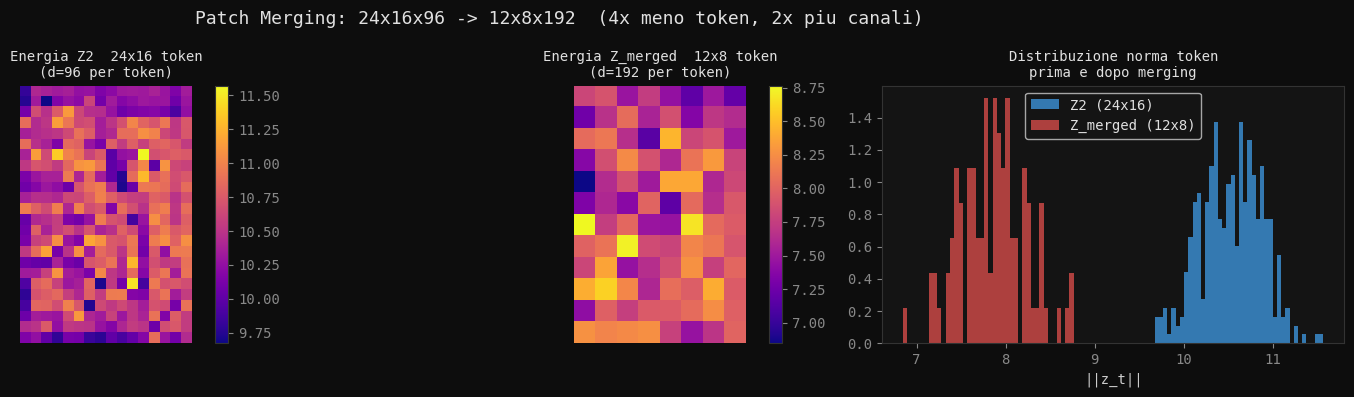

In [10]:
# Patch Merging
class PatchMerging(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.norm      = nn.LayerNorm(4 * dim)
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)

    def forward(self, x, H, W):
        # x: (B, H*W, dim)
        B, T, C = x.shape
        x_2d = x.view(B, H, W, C)

        # Padding se H, W non pari
        if H % 2 != 0 or W % 2 != 0:
            x_2d = F.pad(x_2d, (0, 0, 0, W % 2, 0, H % 2))
        _, Hp, Wp, _ = x_2d.shape

        # Campiona i 4 sotto-pixel in ogni 2x2
        x0 = x_2d[:, 0::2, 0::2, :]   # (B, H/2, W/2, C) — top-left
        x1 = x_2d[:, 1::2, 0::2, :]   # bottom-left
        x2 = x_2d[:, 0::2, 1::2, :]   # top-right
        x3 = x_2d[:, 1::2, 1::2, :]   # bottom-right

        x_cat = torch.cat([x0, x1, x2, x3], dim=-1)   # (B, H/2, W/2, 4C)
        H_new, W_new = Hp // 2, Wp // 2
        x_cat = x_cat.view(B, H_new * W_new, 4 * C)

        x_out = self.reduction(self.norm(x_cat))       # (B, H/2*W/2, 2C)
        return x_out, H_new, W_new

torch.manual_seed(0)
patch_merge = PatchMerging(dim=96).to(DEVICE)

with torch.no_grad():
    Z_merged, H5, W5 = patch_merge(Z2, H4, W4)

T5 = H5 * W5
print(f'Patch Merging:')
print(f'  Input:  {tuple(Z2.shape)}   (B, T4={H4*W4}, d=96)')
print(f'  Output: {tuple(Z_merged.shape)}   (B, T5={T5}, d=192)')
print(f'  Griglia: {H4}x{W4} -> {H5}x{W5}')

# Visualizzazione: token energy prima e dopo merging
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

e_before = Z2[0].detach().cpu().norm(dim=-1).reshape(H4, W4).numpy()
e_after  = Z_merged[0].detach().cpu().norm(dim=-1).reshape(H5, W5).numpy()

im0 = axes[0].imshow(e_before, cmap='plasma', interpolation='nearest')
axes[0].set_title(f'Energia Z2  {H4}x{W4} token\n(d=96 per token)')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(e_after, cmap='plasma', interpolation='nearest')
axes[1].set_title(f'Energia Z_merged  {H5}x{W5} token\n(d=192 per token)')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Confronto distribuzione norma token
n_before = e_before.flatten()
n_after  = e_after.flatten()
axes[2].hist(n_before, bins=40, color='#42a5f5', density=True, alpha=0.7, label=f'Z2 ({H4}x{W4})')
axes[2].hist(n_after,  bins=40, color='#ef5350', density=True, alpha=0.7, label=f'Z_merged ({H5}x{W5})')
axes[2].set_title('Distribuzione norma token\nprima e dopo merging')
axes[2].set_xlabel('||z_t||')
axes[2].legend()

fig.suptitle(f'Patch Merging: {H4}x{W4}x96 -> {H5}x{W5}x192  (4x meno token, 2x piu canali)')
plt.tight_layout()
plt.show()


---
## Stage 5 — Due Swin Block a $d=192$

Stage 5 opera sugli $H_5 \times W_5$ token a dimensione $d=192$,
con $h=4$ teste (dimensione per testa $d_h = 192/4 = 48$).

La struttura è identica a Stage 4: coppia W-MSA + SW-MSA, stesse
formule matematiche, ma:

- Token più "compressi" semanticamente (ogni token = $64\times64$ px)
- Dimensione $d=192$: capacità espressiva doppia rispetto a Stage 4
- Dimensione per testa $d_h=48$: query/key più ricche

**Output finale:**

$$P_4 \in \mathbb{R}^{96 \times H_4 \times W_4}, \quad P_5 \in \mathbb{R}^{192 \times H_5 \times W_5}$$

Entrambi vengono usati dal decoder (cross-attention e branch locale/globale).


In [11]:
# Stage 5: due Swin Block a d=192
torch.manual_seed(0)
block5_wmsa  = SwinBlock(dim=192, num_heads=4, window_size=M, shift=False).to(DEVICE)
block5_swmsa = SwinBlock(dim=192, num_heads=4, window_size=M, shift=True).to(DEVICE)

with torch.no_grad():
    Z5a, attn5a = block5_wmsa(Z_merged, H5, W5)
    Z5b, attn5b = block5_swmsa(Z5a, H5, W5)

# P4 e P5 in formato (B, C, H, W) per compatibilita con il decoder
P4 = Z2.reshape(1, H4, W4, 96).permute(0, 3, 1, 2).contiguous()   # (1, 96, 16, 24)
P5 = Z5b.reshape(1, H5, W5, 192).permute(0, 3, 1, 2).contiguous() # (1, 192, 8, 12)

print(f'P4: {tuple(P4.shape)}   (Stage 4 output)')
print(f'P5: {tuple(P5.shape)}   (Stage 5 output = encoder finale)')

# Salva per il prossimo notebook
np.save('P4_swin.npy', P4.detach().cpu().numpy())
np.save('P5_swin.npy', P5.detach().cpu().numpy())
print('\nSalvati: P4_swin.npy, P5_swin.npy')


P4: (1, 96, 24, 16)   (Stage 4 output)
P5: (1, 192, 12, 8)   (Stage 5 output = encoder finale)

Salvati: P4_swin.npy, P5_swin.npy


---
## Riepilogo — Evoluzione tensore attraverso i due stage Swin

| Step | Tensore | Shape | Token | d | RF cumulativo |
|------|---------|-------|-------|---|----------------|
| Input | $P_3$ | $48 \times H/16 \times W/16$ | — | 48 | 27 px |
| Patch Embed | $\mathbf{Z}$ | $T_4 \times 96$ | $T_4 = H_4 W_4$ | 96 | 64 px |
| Stage 4 (W-MSA) | $\mathbf{Z}^{(1)}$ | $T_4 \times 96$ | $T_4$ | 96 | globale (finestra) |
| Stage 4 (SW-MSA) | $P_4$ | $96 \times H_4 \times W_4$ | $T_4$ | 96 | globale |
| Patch Merge | $\mathbf{Z}'$ | $T_5 \times 192$ | $T_5 = T_4/4$ | 192 | — |
| Stage 5 (W-MSA) | $\mathbf{Z}^{(3)}$ | $T_5 \times 192$ | $T_5$ | 192 | globale |
| Stage 5 (SW-MSA) | $P_5$ | $192 \times H_5 \times W_5$ | $T_5$ | 192 | globale |

Con $H=512, W=768$: $H_4=16, W_4=24, T_4=384$; $H_5=8, W_5=12, T_5=96$.


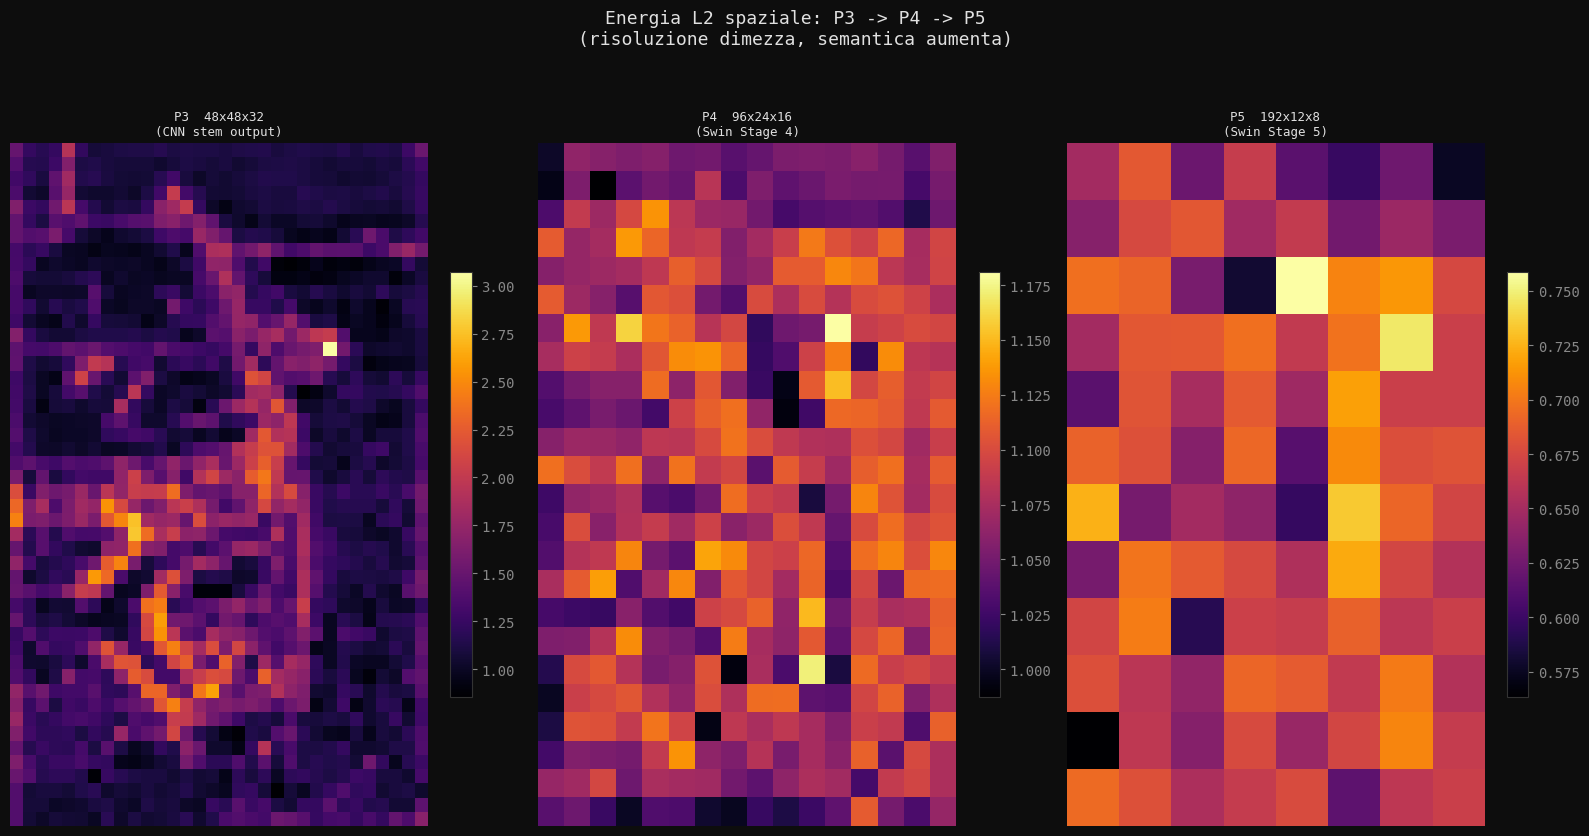

RIEPILOGO DIMENSIONI
P3  (1, 40, 48, 32)               mean=-0.084  std=1.348
P4  (1, 96, 24, 16)               mean=-0.002  std=1.076
P5  (1, 192, 12, 8)               mean=+0.017  std=0.666
Riduzione spaziale P3->P5: 48x32 -> 12x8
Espansione canali P3->P5:  48 -> 192


In [16]:
# Griglia comparativa energia spaziale: P3, P4, P5
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
for ax, (t, label) in zip(axes, [
        (P3, f'P3  48x{H3}x{W3}\n(CNN stem output)'),
        (P4, f'P4  96x{H4}x{W4}\n(Swin Stage 4)'),
        (P5, f'P5  192x{H5}x{W5}\n(Swin Stage 5)')]):
    e = t[0].detach().float().pow(2).mean(0).sqrt().cpu().numpy()
    im = ax.imshow(e, cmap='inferno', interpolation='nearest', aspect='auto')
    ax.set_title(label, fontsize=9)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle('Energia L2 spaziale: P3 -> P4 -> P5\n(risoluzione dimezza, semantica aumenta)', y=1.04)
plt.tight_layout()
plt.show()

print('=' * 55)
print('RIEPILOGO DIMENSIONI')
print('=' * 55)
for name, t in [('P3', P3), ('P4', P4), ('P5', P5)]:
    v = t.detach()
    print(f'{name}  {str(tuple(v.shape)):28s}  mean={v.mean():+.3f}  std={v.std():.3f}')
print('=' * 55)
print(f'Riduzione spaziale P3->P5: {H3}x{W3} -> {H5}x{W5}')
print(f'Espansione canali P3->P5:  48 -> 192')


---
## Libreria o implementazione custom? Raccomandazione finale

### Opzione A — `timm` (PyPI: `pip install timm`)

**Usa `timm` se:** vuoi i pesi pre-addestrati ImageNet-22k su Swin,
non hai bisogno di RoPE custom, e la tua architettura è abbastanza standard.

```python
import timm
swin = timm.create_model('swin_tiny_patch4_window7_224',
                          pretrained=True, features_only=True)
# features_only=True restituisce P3, P4, P5 direttamente
```

Pro: pesi pre-addestrati di qualità, codice testato, facile.
Contro: RoPE non incluso (usa relative position bias classico), difficile
modificare l'architettura interna, patch size fisso.

---

### Opzione B — Implementazione custom (come questo notebook)

**Usa custom se:** hai bisogno di RoPE (per resolution-agnostic), vuoi
controllare esattamente l'architettura, o hai modifiche non standard.

Pro: controllo totale, RoPE integrato, puoi adattare window size e depth.
Contro: devi implementare tutto, nessun peso pre-addestrato direttamente
compatibile (devi fare weight porting manuale dai checkpoint timm/torchvision).

---

### **Raccomandazione concreta per HybridStyleNet**

**Usa `timm` come base + sostituisci il positional encoding con RoPE.**

Il motivo è pratico: i pesi pre-addestrati Swin-Tiny su ImageNet-22k
(disponibili in timm) sono molto migliori di qualsiasi inizializzazione
casuale nel regime few-shot — e il beneficio supera di gran lunga il
costo del weight porting.

La strategia è:

1. Carica `swin_tiny_patch4_window7_224` da timm con `pretrained=True`
2. Sostituisci il modulo di positional embedding con il tuo RoPE
3. Fine-tuna dalla Phase 0 su MIT-Adobe FiveK

Il peso pre-addestrato è su immagini $224\times224$ con patch $4\times4$,
ma grazie a RoPE generalizza immediatamente a qualsiasi risoluzione —
questo è esattamente il punto di RoPE.
